In [3]:
%%bash

g++ -std=c++17 -Wall main.cpp Mesh.cpp Flux.cpp Solver.cpp Cell.cpp -o myprogram



Mesh.cpp: In member function ‘void Mesh::assemble_conserved()’:
Mesh.cpp:298:23: warning: unused variable ‘arr’ [-Wunused-variable]
  298 |     array<double,742> arr;
      |                       ^~~


In [4]:
%%bash
./myprogram

Setting ambient Conditions...

In [5]:
import numpy as np
import matplotlib.pyplot as plt
def compute_all_areas(x,y,visualize=False):
    def triangle_area_2d(a, b, c):
        u = np.array(b) - np.array(a)
        v = np.array(c) - np.array(a)
        return 0.5 * abs(u[0]*v[1] - u[1]*v[0])
    xx =x
    yy = y
    p1 = [xx[0:-1,0:-1],yy[0:-1,0:-1]]
    p2 = [xx[1:,0:-1],yy[1:,0:-1]] 
    p3 = [xx[0:-1,1:],yy[0:-1,1:]] 
    p4 = [xx[1:,1:],yy[1:,1:]]
    areas = triangle_area_2d(p1,p2,p3 ) + triangle_area_2d(p1, p3, p4)

    if visualize:
        midpoint_tempx = (xx[1:,:]+xx[0:-1,:])/2
        midpointxx = (midpoint_tempx[:,1:]+midpoint_tempx[:,0:-1])/2
        midpoint_tempy = (yy[1:,:]+yy[0:-1,:])/2
        midpointyy = (midpoint_tempy[:,1:]+midpoint_tempy[:,0:-1])/2
        plt.scatter(midpointxx.flatten(),midpointyy.flatten(),c=areas.flatten())
        plt.colorbar()
        plt.show()
    return np.einsum("ij,jkl->ikl",np.ones((4,1)),areas[np.newaxis,:,:])  

In [6]:
#x = np.fromfile("Ramp_Coarse_xx.bin", dtype=np.float64).reshape((NI,NJ))
#y = np.fromfile("Ramp_Coarse_yy.bin",dtype=np.float64).reshape((NI,NJ))
#np.savetxt("Ramp_Coarse_xx.csv",x,delimiter=",")
#np.savetxt("Ramp_Coarse_yy.csv",y,delimiter=",")


In [7]:
import numpy as np
import matplotlib.pyplot as plt
NI = 17  # same as in C++
NJ = 53

#residual = np.fromfile("midpoint_yy.bin", dtype=np.float64).reshape((NI-1, NJ-1))

#print(residual)
#plt.imshow(residual)

#plt.colorbar()

In [9]:
NI = 16  # same as in C++
NJ = 52
NI = 128  # same as in C++
NJ = 416
#midpointxx = np.fromfile("midpoint_xx.bin", dtype=np.float64).reshape((NI-1, NJ-1))
#midpointyy = np.fromfile("midpoint_yy.bin", dtype=np.float64).reshape((NI-1, NJ-1))
volume = np.fromfile("volume2.bin", dtype=np.float64).reshape((NI, NJ))
#plt.scatter(midpointxx,midpointyy,c=volume)

-2.8850367563365846e-05


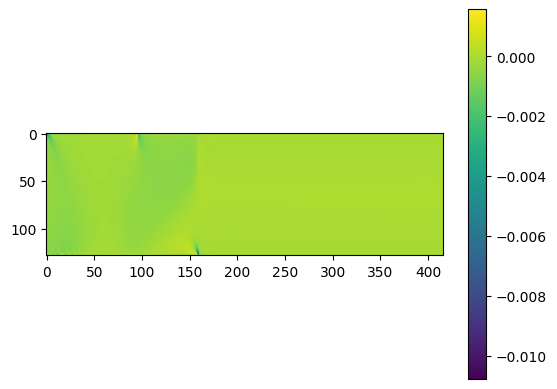

In [10]:
print(np.median(volume))
plt.imshow(volume)
plt.colorbar()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# Example data (replace this with your real data)
data = np.abs(np.random.randn(100, 100))  # Ensure no zeros or negatives for log scale

# Plot with logarithmic color normalization
plt.figure(figsize=(6, 5))
img = plt.imshow(np.abs(residual), norm=LogNorm(), cmap='viridis')
plt.colorbar(img, label='Log-scaled values')
plt.title("Logarithmic Color Scale")
plt.show()

NameError: name 'residual' is not defined

<Figure size 600x500 with 0 Axes>